In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_PID, simular_step_test

from utils.plots import plot_results

In [2]:
SEED = 23

np.random.seed(SEED)

In [3]:
tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


Funções auxiliares

In [4]:
def ajuste_string(individuo: list = None, tipo_param: str = "Kp"):
    if tipo_param == "Ti":
        individuo = ['+'] + individuo
        
    digitos_completar = 6 - len(individuo)
    while digitos_completar > 0:
        individuo.append('0')
        digitos_completar-=1
    return individuo

def gerar_mask_cruzamento():
    mask = np.array([
                    0,
                    np.random.randint(0, 2),
                    0,
                    np.random.randint(0, 2),
                    np.random.randint(0, 2),
                    np.random.randint(0, 2)
                ])
    
    return mask

def gerar_populacao_inicial(tamanho_povo):
    # g init
    gen = np.column_stack([
        -np.round(np.random.uniform(0, 5, tamanho_povo), 3),  # sempre negativo
        np.round(np.random.uniform(0, 10, tamanho_povo), 3),
    ])

    for tuning_parameter_indice in range(len(gen)):
        # Checa casos em que Ti = 0
        while gen[tuning_parameter_indice, 1] == 0:
            # re-gera aleatoriamente 
            gen[tuning_parameter_indice, 1] = np.round(np.random.uniform(0, 10), 3)
    
    return gen

def ordenar_populacao(povo):
    # Ordena pelo erro (usando valor absoluto)
    # Agora apenas os fortes têm erros correspondentes
    indices_ordenados = np.argsort(np.abs(povo["erros"]))

    povo_ordenado = {
        "candidatos": [povo["candidatos"][i] for i in indices_ordenados],
        "erros": [povo["erros"][i] for i in indices_ordenados]
    }

    return povo_ordenado

def grafico_convergencia(historico_erro):
    tempo = np.arange(len(historico_erro))

    plt.figure(figsize=(8,4))

    plt.plot(
        tempo,
        historico_erro,
        color='lightblue',
        linewidth=1.5
    )

    plt.scatter(
        tempo,
        historico_erro,
        color='blue',
        s=20
    )

    plt.xlabel("Geração")
    plt.ylabel("Erro")
    plt.grid(True, alpha=0.3)

    plt.show()

def selecao(erro_individuo_lim, Xsp, gen, tf, dt, pert, t_pert, Sf_pert):
    erro_min = np.inf
    fortes = []
    fracos = []
    erros_fortes = []
    erros_fracos = []

    for individuo in gen:
        erro_individuo = np.inf
        # só pode ser selecionado como forte se Ti != 0
        if individuo[1] != 0:
            t1, X1, S1, D1, IAE, ISE, erro = simular_PID(Kc=individuo[0], Ti=individuo[1], Xsp=Xsp, D0=D0, states=states, tempo_final=tf, dt=dt, show=False, pert=pert, t_pert=t_pert, Sf_pert=Sf_pert)
            erro_individuo = IAE

        if erro_individuo <= erro_individuo_lim: 
            fortes.append(individuo)
            erros_fortes.append(erro_individuo)
        else:
            fracos.append(individuo)
            erros_fracos.append(erro_individuo)
        
        # menor erro dentro dessa geracao
        if np.abs(erro_min) > np.abs(erro_individuo):
            erro_min = erro_individuo
                
    return fortes, fracos, erros_fortes, erros_fracos, erro_min

def cruzamento(fortes, pc: int = 1):
    N = len(fortes)

    filhos = np.zeros(shape=(N, 2))
    
    for i in range(0, N, 2):
        # escolha dos pais
        idx_pai, idx_mae = np.random.choice(len(fortes),size=2,replace=False)
        
        # sorteia se esse par vai copular
        r = np.random.uniform(0, 1)
        if r <= pc:
            # crossover para o Kp
            pai = fortes[idx_pai, 0]
            mae = fortes[idx_mae, 0]
                
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Kp"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Kp"))

            # crossover para o Ti
            pai = fortes[idx_pai, 1]
            mae = fortes[idx_mae, 1]
                
            arr_p = np.array(ajuste_string(list(str(pai)), tipo_param="Ti"))
            arr_m = np.array(ajuste_string(list(str(mae)), tipo_param="Ti"))

            # mascaras
            mask_Kp = gerar_mask_cruzamento()
            mask_Ti = gerar_mask_cruzamento()
             
            # gera filho 1
            filhos[i, 0] = float(''.join(np.where(mask_Kp, arr_m, arr_p)))
            filhos[i, 1] = float(''.join(np.where(mask_Ti, arr_m, arr_p)))

            if i != N-1:
                # gera filho 2
                filhos[i + 1, 1] = float(''.join(np.where(mask_Ti, arr_p, arr_m)))
                filhos[i + 1, 0] = float(''.join(np.where(mask_Kp, arr_p, arr_m)))
        else:
            # caso não possam acasalar, os pais são sujeitos direto a mutação
            filhos[i] = fortes[idx_mae]
            filhos[i + 1] = fortes[idx_pai]

    return filhos

def mutacao_gene(cromossomo, pm):
    for gene in range(len(cromossomo)):
            if (gene != 0 and gene != 2):
                r = np.random.uniform(0, 1)
                if r < pm:
                    cromossomo[gene] = str(np.random.randint(0, 10))
    
    return cromossomo
    
def mutacao(populacao, pm: float = 0.1):
    for i in range(len(populacao)):
        Kp = populacao[i, 0]
        Ti = populacao[i, 1]
        
        cromossomo_Kp = np.array(ajuste_string(list(str(Kp)), tipo_param="Kp"))
        cromossomo_Ti = np.array(ajuste_string(list(str(Ti)), tipo_param="Ti"))
        
        cromossomo_Kp = mutacao_gene(cromossomo_Kp, pm)
        cromossomo_Ti = mutacao_gene(cromossomo_Ti, pm)
        
        populacao[i, 0] = float(''.join(cromossomo_Kp))
        populacao[i, 1] = float(''.join(cromossomo_Ti))
        
    return populacao


In [5]:
def sobrevivenciaMaisApto(iter_max, erro_desejado,erro_individuo_lim, gen, Xsp, tf, dt, pert=False, t_pert: int = None, Sf_pert: int = None, flag_fracos: bool = True):
    df = None
    historico_erro = []
    while iter_max > 0:
        # seleção da geração
        fortes, fracos, erros_fortes, erros_fracos, erro_min = selecao(erro_individuo_lim= erro_individuo_lim, Xsp=Xsp, gen= gen, tf=tf, dt=dt, pert=pert, t_pert=t_pert, Sf_pert= Sf_pert)
             
        # salva erro minimo de cada geração
        historico_erro.append(erro_min)
        
        dict_populacao = {
                "candidatos": fortes,
                "erros": erros_fortes
            }
        
        # o menor custo da geração foi top, para aqui
        if abs(erro_min) < erro_desejado:
            print("ola")
            break
        
        if iter_max > 1:
            filhos = np.empty((0, 2))
            if len(fortes) >= 2:
                filhos = cruzamento(np.array(fortes))
                filhos = mutacao(filhos) 

            # nova geracao
            gen = np.concatenate([mutacao(np.array(fracos)), filhos]) if len(fracos) > 0 else filhos

        if iter_max == 1 and len(fortes) == 0:
            # Se na ultima geração só houver fracos, o escolhido será o melhor entre eles
            dict_populacao = {
                "candidatos": fracos,
                "erros": erros_fracos
            }
            
        iter_max-=1
        
    povo = ordenar_populacao(dict_populacao)
    print(povo)
    Kp = povo["candidatos"][0][0]
    Ti = povo["candidatos"][0][1]
    
    return Kp, Ti, historico_erro


Mudança no setpoint ($X_{sp} = 0.34$)

In [6]:
tamanho_povo = 100
N = 10
erro_individuo_lim = 1e-2
erro_desejado = 6e-5
Xsp_novo = 0.34

gen = gerar_populacao_inicial(tamanho_povo)

Kp_AG, Ti_AG, historico_erro = sobrevivenciaMaisApto(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, gen=gen, Xsp=Xsp_novo, dt=0.1, tf = 50)

{'candidatos': [array([-8.197,  1.835]), array([-7.405,  1.356]), array([-7.389,  0.317]), array([-6.873,  1.648]), array([-6.603,  1.964]), array([-6.777,  0.888]), array([-8.922,  2.863]), array([-9.06 ,  2.914]), array([-6.049,  0.969]), array([-5.826,  0.222]), array([-5.531,  1.852]), array([-7.895,  2.845]), array([-6.311,  0.119]), array([-7.232,  2.708]), array([-8.411,  3.192]), array([-8.597,  3.271]), array([-7.976,  3.712]), array([-7.387,  0.034]), array([-3.956,  1.076]), array([-7.869,  3.746]), array([-6.785,  0.034]), array([-9.01 ,  4.401]), array([-8.556,  4.477]), array([-3.231,  0.81 ]), array([-6.937,  3.809]), array([-6.929,  4.001]), array([-3.065,  1.85 ]), array([-8.094,  4.932]), array([-4.863,  3.137]), array([-8.298,  5.484]), array([-8.675,  5.736]), array([-8.235,  5.917]), array([-2.968,  2.171]), array([-6.199,  4.575]), array([-7.604,  5.677]), array([-1.749,  0.309]), array([-1.78 ,  0.444]), array([-7.199,  5.661]), array([-2.842,  2.313]), array([-4

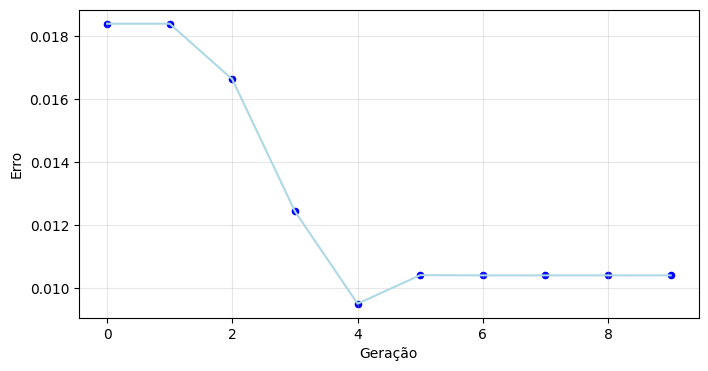

In [7]:
grafico_convergencia(historico_erro)

In [8]:
print(D0)

0.35


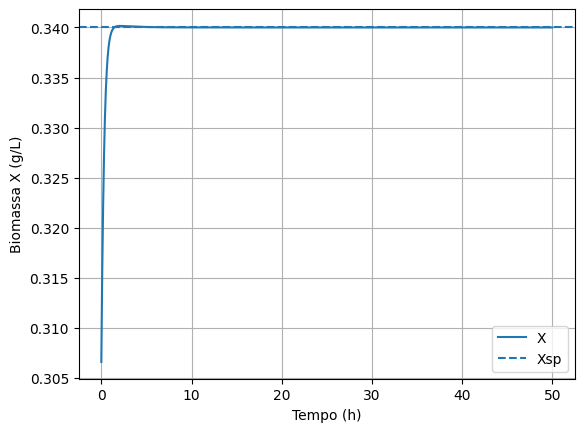

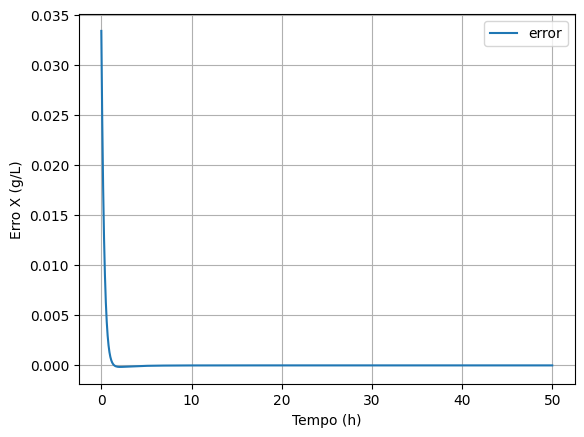

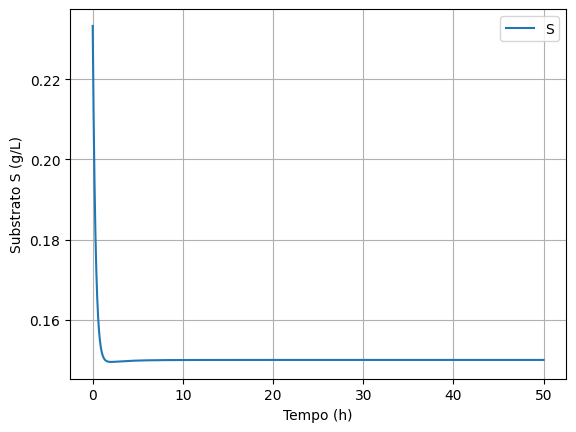

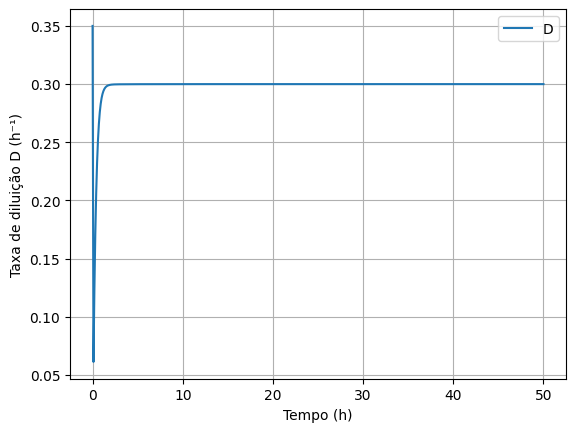

IAE: 0.01040768523677527, ISE: 0.00017981003244351839, Erro (Xsp - X): -9.807821221841095e-12
Kp: -8.197, Ti: 1.835


In [9]:
ttop, Xtop, Stop, Dtop, IAE_top, ISE_top, erro = simular_PID(Kc=Kp_AG, Ti=Ti_AG, Xsp=Xsp_novo, states=states, tempo_final=50, dt=0.1, show=True)
print(f"IAE: {IAE_top}, ISE: {ISE_top}, Erro (Xsp - X): {erro[-1]}")
print(f"Kp: {Kp_AG}, Ti: {Ti_AG}")

Com pertubação (+20% em SF)

In [10]:
Kp_AG_pert, Ti_AG_pert, historico_erro_pert = sobrevivenciaMaisApto(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, gen=gen, Xsp=Xsp, dt=0.1, tf = 50, pert=True, t_pert=20, Sf_pert = 1.2)

{'candidatos': [array([-8.153,  1.646]), array([-3.152,  0.919]), array([-3.863,  1.225]), array([-8.595,  2.879]), array([-5.417,  1.852]), array([-5.148,  1.805]), array([-6.981,  2.655]), array([-3.074,  1.177]), array([-2.676,  1.047]), array([-9.038,  5.266]), array([-3.475,  2.033]), array([-5.102,  3.584]), array([-9.515,  7.137]), array([-7.982,  6.054]), array([-9.102,  7.27 ]), array([-5.354,  4.271]), array([-4.242,  3.38 ]), array([-6.943,  5.59 ]), array([-4.391,  3.518]), array([-4.349,  3.524]), array([-5.095,  4.458]), array([-3.956,  3.705]), array([-4.19 ,  4.015]), array([-3.398,  3.309]), array([-3.837,  3.757]), array([-2.95 ,  3.035]), array([-5.567,  5.819]), array([-3.111,  3.277]), array([-1.389,  1.339]), array([-6.814,  7.613]), array([-4.987,  5.485]), array([-1.684,  1.8  ]), array([-7.197,  8.343]), array([-6.63 ,  7.637]), array([-4.95 ,  5.821]), array([-7.679,  9.569]), array([-6.11 ,  7.703]), array([-4.42 ,  5.645]), array([-2.688,  3.461]), array([-3

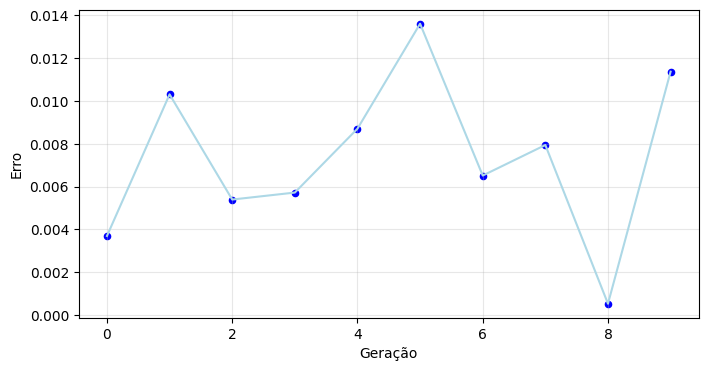

In [11]:
grafico_convergencia(historico_erro_pert)

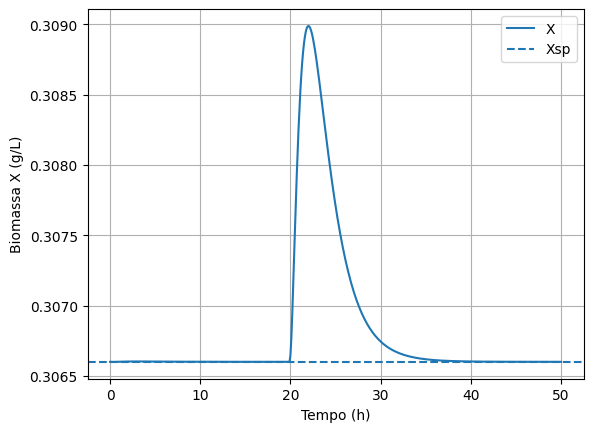

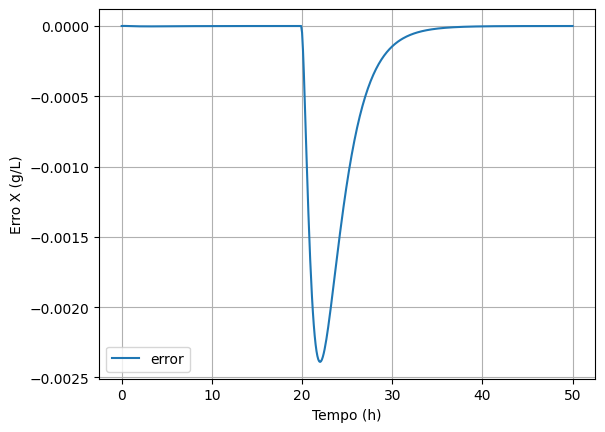

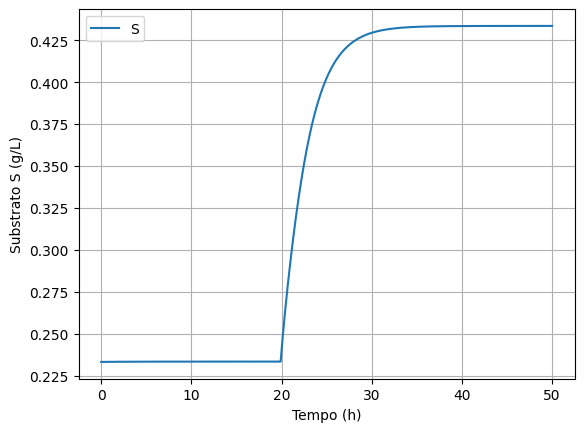

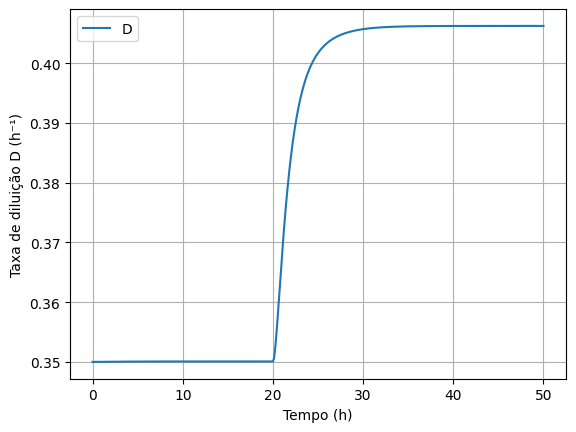

IAE: 0.011362652120260497, ISE: 1.802909947407971e-05, Erro (Xsp - X): -4.085192817360195e-08
Kp: -8.153, Ti: 1.646


In [12]:
ttop_pert, Xtop_pert, Stop_pert, Dtop_pert, IAE_top_pert, ISE_top_pert, erro_pert = simular_PID(Kc=Kp_AG_pert, Ti=Ti_AG_pert, Xsp=Xsp, D0=D0, states=states, tempo_final=50, dt=0.1, show=True, pert=True, t_pert=20, Sf_pert = 1.2)
print(f"IAE: {IAE_top_pert}, ISE: {ISE_top_pert}, Erro (Xsp - X): {erro_pert[-1]}")
print(f"Kp: {Kp_AG_pert}, Ti: {Ti_AG_pert}")